# Libraries

In [106]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [107]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240611 - Ag60 GDE_0.9 M K2SO4_pH3

11-Aug-26  09:58 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  09:50 PM    <DIR>          .ipynb_checkpoints
12-Jun-24  11:44 AM            36,247 0p9M_pH3 K2SO4_20240612_0944_1min - Copy.xlsx
30-Jul-26  11:50 AM            43,948 0p9M_pH3 K2SO4_20240612_0944_1min.xlsx
12-Jun-24  11:44 AM            11,575 0p9M_pH3 K2SO4_20240612_0944_5min.xlsx
12-Jun-24  11:44 AM           247,066 0p9M_pH3 K2SO4_20240612_0944_Line_1.csv
12-May-25  02:06 PM           685,010 20240611 - Ag60 GDE_0.9 M K2SO4_pH3.ipynb
11-Aug-26  09:58 AM           667,709 20240611 - Ag60 GDE_0.9 M K2SO4_pH3-CORRECTED.ipynb
11-Aug-26  09:57 AM               577 20240611_0.9 M K2SO4_pH3_Energy Consumption.csv
03-Aug-26  05:44 PM             5,305 20240611_0.9M K2SO4_pH3.csv
11-Aug-26  09:57 AM             1,402 20

# Load Data

In [108]:
Book = "Book_20240611 - Ag60 GDE_0.9 M K2SO4_pH3.xlsx"
Book = pd.read_excel(Book)
Book.head(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60.0,44.780690,K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-06-11 16:08:06.762,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
1,Ag60 GDE in PTFE holder,60.0,51.516533,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:42:45.000,0.577288,0.002869,...,0.000026,0.000299,0.999578,0.000008,0.001445,0.016300,NaN,0.017744,0.009996,NaN
2,Ag60 GDE in PTFE holder,60.0,53.308384,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:57:45.000,0.827288,0.131463,...,0.000026,0.000299,0.999578,0.000008,0.001495,0.016866,NaN,0.018361,0.009996,108.341981


In [109]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
60,Ag60 GDE in PTFE holder,60.0,57.20,K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-12 07:28:23,15.34,19.774278,...,0.102896,0.694440,0.012437,0.464568,0.251291,NaN,0.715859,0.006944,101.577529,57.20
61,Ag60 GDE in PTFE holder,60.0,60.49,K2SO4,0.05 M H2SO4,CCM-CEM,-3.1,2024-06-12 07:43:24,15.59,20.170852,...,0.103609,0.690164,0.013758,0.496673,0.267557,NaN,0.764230,0.006902,NaN,60.49
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,20.380252,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Temp from pH meter

In [110]:
Temp = "2024-06-12_101129.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 25.1348731884058
Temp C median: 24.1


### Power Supply

In [111]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.17V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,11.06.2024 16:08:06.762
1,40.00V,2.49V,0.100A,0.111A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,11.06.2024 16:08:11.761


In [112]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.17V
0.100A 1    2.49V
       2    2.53V

In [113]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                 Time  I actual  U actual
0 2024-06-11 16:00:00     0.124      3.03
1 2024-06-11 18:00:00     0.272      3.52
2 2024-06-11 20:00:00     0.520      4.17
3 2024-06-11 22:00:00     0.771      4.77
4 2024-06-12 00:00:00     1.020      5.39
5 2024-06-12 02:00:00     1.516      6.32
6 2024-06-12 04:00:00     2.018      7.22
7 2024-06-12 06:00:00     3.017      9.85
8 2024-06-12 08:00:00     3.013     10.77


In [114]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-06-11 16:00:00     0.124      3.03
1 2024-06-11 18:00:00     0.272      3.52
2 2024-06-11 20:00:00     0.520      4.17
3 2024-06-11 22:00:00     0.771      4.77
4 2024-06-12 00:00:00     1.020      5.39
5 2024-06-12 02:00:00     1.516      6.32
6 2024-06-12 04:00:00     2.018      7.22
7 2024-06-12 06:00:00     3.017      9.85


In [115]:
# power_sup["U actual"] = power_sup["U actual"].str.replace("V", "", regex=False).astype(float)
# power_sup["I set"] = power_sup["I set"].str.replace("A", "", regex=False).astype(float)
# cell_voltage = power_sup.groupby("I set")["U actual"].mean()
# cell_voltage

In [116]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.124,3.03
0.272,3.52
0.520,4.17
0.771,4.77
1.020,5.39
1.516,6.32
2.018,7.22
3.017,9.85


In [117]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.124,3.03,1.24
0.272,3.52,2.72
0.520,4.17,5.20
0.771,4.77,7.71
1.020,5.39,10.20
1.516,6.32,15.16
2.018,7.22,20.18
3.017,9.85,30.17


## Flow rate

In [118]:
flow_rate = "0p9M_pH3 K2SO4_20240612_0944_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-06-12 09:44:29.242000,NaN
1,Software version,Aurora 1.0.6,NaN
2,Instrument name,0p9M_pH3 K2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6f:0d:ec,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [119]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-06-11 14:08:00.010000,44.78069,22.390345
1,2024-06-11 14:08:59.971000,45.432448,22.716224
2,2024-06-11 14:10:00.019000,45.691795,22.845897
3,2024-06-11 14:10:59.981000,45.99149,22.995745
4,2024-06-11 14:12:00.029000,46.677056,23.338528
...,...,...,...
922,2024-06-12 05:30:00.029000,58.133272,29.066636
923,2024-06-12 05:30:59.990000,58.223581,29.11179
924,2024-06-12 05:32:00.038000,57.470013,28.735007
925,2024-06-12 05:33:00,58.122012,29.061006


In [120]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-11 14:00:00      44.78069     59.981351      54.731926   
1 2024-06-11 16:00:00     58.624459      61.94961      60.712006   
2 2024-06-11 18:00:00     60.434565      62.74746      61.554722   
3 2024-06-11 20:00:00     60.736191     63.496548      61.920106   
4 2024-06-11 22:00:00     61.416183     63.890248      62.814774   
5 2024-06-12 00:00:00     62.222381     67.635302      65.716986   
6 2024-06-12 02:00:00     65.068551     70.280081      69.013066   
7 2024-06-12 04:00:00     52.295932     79.982653       69.32745   

  Flow_rate_median  
0         56.11228  
1         60.81543  
2        61.534884  
3        61.919563  
4        62.873138  
5        65.841692  
6        69.180571  
7        78.218644  


### Correction for dry flow

In [121]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.390 L/mol
p_sat = 3.0025 kPa -> x(H2O) = 2.96 % -> dry factor 0.97037


In [122]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [123]:
print(flow_rate)

           Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0 2024-06-11 14:00:00      44.78069     59.981351      54.731926   
1 2024-06-11 16:00:00     58.624459      61.94961      60.712006   
2 2024-06-11 18:00:00     60.434565      62.74746      61.554722   
3 2024-06-11 20:00:00     60.736191     63.496548      61.920106   
4 2024-06-11 22:00:00     61.416183     63.890248      62.814774   
5 2024-06-12 00:00:00     62.222381     67.635302      65.716986   
6 2024-06-12 02:00:00     65.068551     70.280081      69.013066   
7 2024-06-12 04:00:00     52.295932     79.982653       69.32745   

  Flow_rate_median Flow_rate_min_dry Flow_rate_max_dry Flow_rate_mean_dry  \
0         56.11228         43.453749         58.203984           53.11011   
1         60.81543         56.887299         60.113919          58.912988   
2        61.534884         58.643768         60.888128          59.730733   
3        61.919563         58.936457         61.615019           60.08529   
4 

In [124]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
# dfflow_rate = dfflow_rate.iloc[:-2].reset_index(drop=True)
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-06-11 14:00:00,44.78069,59.981351,54.731926,56.11228,43.453749,58.203984,53.11011,54.449562,0.124,3.03
1,2024-06-11 16:00:00,58.624459,61.94961,60.712006,60.81543,56.887299,60.113919,58.912988,59.013348,0.272,3.52
2,2024-06-11 18:00:00,60.434565,62.74746,61.554722,61.534884,58.643768,60.888128,59.730733,59.711483,0.520,4.17
3,2024-06-11 20:00:00,60.736191,63.496548,61.920106,61.919563,58.936457,61.615019,60.08529,60.084763,0.771,4.77
4,2024-06-11 22:00:00,61.416183,63.890248,62.814774,62.873138,59.596299,61.997053,60.953447,61.010082,1.020,5.39
5,2024-06-12 00:00:00,62.222381,67.635302,65.716986,65.841692,60.378608,65.631133,63.769661,63.890671,1.516,6.32
6,2024-06-12 02:00:00,65.068551,70.280081,69.013066,69.180571,63.14044,68.197542,66.968071,67.130613,2.018,7.22
7,2024-06-12 04:00:00,52.295932,79.982653,69.32745,78.218644,50.746299,77.612607,67.273139,75.90087,3.017,9.85


In [125]:
# dfflow_rate.to_csv('20240611_0.9M K2SO4_pH3_flow rate.csv')

## Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [126]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100 #10000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.124,3.03,1.24,124.0
0.272,3.52,2.72,272.0
0.520,4.17,5.20,520.0


In [127]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.124,3.03,1.24,124.0,2705.184
0.272,3.52,2.72,272.0,6893.568
0.520,4.17,5.20,520.0,15612.480
0.771,4.77,7.71,771.0,26479.224
1.020,5.39,10.20,1020.0,39584.160
1.516,6.32,15.16,1516.0,68984.064
2.018,7.22,20.18,2018.0,104903.712
3.017,9.85,30.17,3017.0,213965.640


In [128]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.124,3.03,1.24,124.0,2705.184,0.000751
0.272,3.52,2.72,272.0,6893.568,0.001915
0.520,4.17,5.20,520.0,15612.480,0.004337
0.771,4.77,7.71,771.0,26479.224,0.007355
1.020,5.39,10.20,1020.0,39584.160,0.010996
1.516,6.32,15.16,1516.0,68984.064,0.019162
2.018,7.22,20.18,2018.0,104903.712,0.029140
3.017,9.85,30.17,3017.0,213965.640,0.059435


In [129]:
# dfcell_voltage.to_csv('20240611_0.9 M K2SO4_pH3_Energy Consumption.csv')

## FE(CO) and FE(H2)

## Integer Duration ("Applied Current /A" - Values optimization)

In [130]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60.0,44.78,K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-06-11 16:08:06.762,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,44.78,0.0
1,Ag60 GDE in PTFE holder,60.0,51.52,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:42:45.000,0.58,0.002869,...,0.999578,0.000008,0.001445,0.016300,NaN,0.017744,0.009996,NaN,51.52,0.0
2,Ag60 GDE in PTFE holder,60.0,53.31,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:57:45.000,0.83,0.131463,...,0.999578,0.000008,0.001495,0.016866,NaN,0.018361,0.009996,108.341981,53.31,0.0
3,Ag60 GDE in PTFE holder,60.0,54.39,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:12:44.000,1.08,0.150315,...,0.978454,0.002565,0.069788,0.863876,NaN,0.933664,0.009785,NaN,54.39,1.0
4,Ag60 GDE in PTFE holder,60.0,55.57,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:27:44.000,1.33,0.166076,...,0.979798,0.002131,0.081540,0.867757,NaN,0.949297,0.009798,108.015508,55.57,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Ag60 GDE in PTFE holder,60.0,78.69,K2SO4,0.05 M H2SO4,CCM-CEM,-3.100,2024-06-12 06:43:20.000,14.59,18.676850,...,0.753339,0.008164,0.440442,0.360791,NaN,0.801233,0.007533,NaN,78.69,14.0
58,Ag60 GDE in PTFE holder,60.0,78.19,K2SO4,0.05 M H2SO4,CCM-CEM,-3.100,2024-06-12 06:58:21.000,14.84,19.288322,...,0.705003,0.010904,0.605201,0.343158,NaN,0.948360,0.007050,101.895478,78.19,14.0
59,Ag60 GDE in PTFE holder,60.0,55.53,K2SO4,0.05 M H2SO4,CCM-CEM,-3.100,2024-06-12 07:13:22.000,15.09,19.566056,...,0.699066,0.011359,0.444305,0.242257,NaN,0.686562,0.006991,NaN,55.53,15.0
60,Ag60 GDE in PTFE holder,60.0,57.20,K2SO4,0.05 M H2SO4,CCM-CEM,-3.100,2024-06-12 07:28:23.000,15.34,19.774278,...,0.694440,0.012437,0.464568,0.251291,NaN,0.715859,0.006944,101.577529,57.20,15.0


## Current Density

In [131]:
Book["Current Density"] = (Book['Applied current / A']/10)*10000 #mA
Book.head(15)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60.0,44.78,K2SO4,0.05 M H2SO4,CCM-CEM,0.000,2024-06-11 16:08:06.762,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,44.78,0.0,0.0
1,Ag60 GDE in PTFE holder,60.0,51.52,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:42:45.000,0.58,0.002869,...,0.000008,0.001445,0.016300,NaN,0.017744,0.009996,NaN,51.52,0.0,-125.0
2,Ag60 GDE in PTFE holder,60.0,53.31,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 16:57:45.000,0.83,0.131463,...,0.000008,0.001495,0.016866,NaN,0.018361,0.009996,108.341981,53.31,0.0,-125.0
3,Ag60 GDE in PTFE holder,60.0,54.39,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:12:44.000,1.08,0.150315,...,0.002565,0.069788,0.863876,NaN,0.933664,0.009785,NaN,54.39,1.0,-125.0
4,Ag60 GDE in PTFE holder,60.0,55.57,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:27:44.000,1.33,0.166076,...,0.002131,0.081540,0.867757,NaN,0.949297,0.009798,108.015508,55.57,1.0,-125.0
5,Ag60 GDE in PTFE holder,60.0,56.35,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:42:45.000,1.58,0.183679,...,0.001757,0.091397,0.837476,NaN,0.928873,0.009813,NaN,56.35,1.0,-125.0
6,Ag60 GDE in PTFE holder,60.0,56.89,K2SO4,0.05 M H2SO4,CCM-CEM,-0.125,2024-06-11 17:57:45.000,1.83,0.194785,...,0.001556,0.102102,0.819864,NaN,0.921966,0.009821,108.079711,56.89,1.0,-125.0
7,Ag60 GDE in PTFE holder,60.0,58.79,K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-06-11 18:12:46.000,2.08,0.204460,...,0.001437,0.051776,0.385403,NaN,0.437179,0.009827,NaN,58.79,2.0,-270.0
8,Ag60 GDE in PTFE holder,60.0,58.90,K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-06-11 18:27:46.000,2.33,0.005239,...,0.001329,0.054499,0.379357,NaN,0.433856,0.009831,108.121598,58.90,2.0,-270.0
9,Ag60 GDE in PTFE holder,60.0,60.08,K2SO4,0.05 M H2SO4,CCM-CEM,-0.270,2024-06-11 18:42:47.000,2.58,0.203238,...,0.001340,0.001433,0.476014,NaN,0.477447,0.009821,NaN,60.08,2.0,-270.0


## FE(CO)

In [132]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [133]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.15       # gas temperature at the meter       [K]  (~23 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.390 L/mol


In [134]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.124, 0.272, 0.52, 0.771, 1.02, 1.516, 2.018, 3.017]

In [135]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[7, 8, 8, 8, 8, 8, 8, 7]

In [136]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))
# rows[["c(H2)", "c(CO)","FE(H2)", "FE(CO)"]].head(50)

                     c(H2)  c(CO)
Applied current / A              
0.124                0.001  0.014
0.272                0.002  0.029
0.520                0.003  0.053
0.771                0.008  0.078
1.020                0.020  0.092
1.516                0.057  0.103
2.018                0.099  0.108
3.017                0.181  0.104


In [137]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 98.2 / 77.2 %


In [138]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [139]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.83].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.58].index)

rows = rows.drop(rows[rows['Duration / h'] == 12.09].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.34].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.09].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.34].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.59].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
3,Ag60 GDE in PTFE holder,60.0,54.39,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:12:44,1.08,0.150315,...,54.39,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,93.873611
4,Ag60 GDE in PTFE holder,60.0,55.57,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:27:44,1.33,0.166076,...,55.57,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,93.426578
5,Ag60 GDE in PTFE holder,60.0,56.35,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:42:45,1.58,0.183679,...,56.35,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,90.137163
6,Ag60 GDE in PTFE holder,60.0,56.89,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:57:45,1.83,0.194785,...,56.89,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,88.624637
7,Ag60 GDE in PTFE holder,60.0,60.73,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:57:48,3.83,0.227660,...,60.73,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.685403
8,Ag60 GDE in PTFE holder,60.0,60.44,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:42:48,3.58,0.222699,...,60.44,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.906034
9,Ag60 GDE in PTFE holder,60.0,60.13,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:12:47,3.08,0.211829,...,60.13,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,89.597577
10,Ag60 GDE in PTFE holder,60.0,60.60,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:27:48,3.33,0.218270,...,60.60,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.217312
14,Ag60 GDE in PTFE holder,60.0,59.89,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 18:57:47,2.83,0.205780,...,59.89,2.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,84.509451
18,Ag60 GDE in PTFE holder,60.0,62.69,K2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-06-11 20:57:52,4.83,0.357520,...,62.69,4.0,-520.0,0.520,0.520,59.730733,58.643768,60.888128,59.711483,83.311175


### Mean FE per current density

In [140]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        124    8.431349   83.084148      8.447030     83.334841   0.596611   
1        272    5.668968   83.514187      5.653687     84.563626   0.098842   
2        520    5.122147   82.609325      5.212901     83.647153   0.092809   
3        771    8.863548   81.410817      9.043905     81.684404   0.205093   
4       1020   17.175164   73.166397     17.430809     72.976398   0.525738   
5       1516   32.625244   57.834752     33.056261     57.542705   0.568540   
6       2018   41.986725   47.431678     44.431578     47.457486   2.218773   
7       3017   62.304512   34.125861     62.635899     34.118082   0.794855   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0   1.852263   1.193223   3.704527   7.772886  ...   0.001456     0.001459  4   
1   1.116513   0.221018   2.496598   5.499403  ...   0.001982     0.001976  5   
2   1.033971   0.207527   2.312030   5.084528

## FE(H2)

In [141]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]
# Book.at[0, 'FE(H2)'] = 0
# Book["FE(H2)"] = Book["FE(H2)"] * 100
# Book.head(20)
print(rows["FE(H2)"])

3      7.016735
4      8.024937
5      8.869123
6      9.814603
7      5.946697
8      5.828639
9      5.499403
10     5.653687
14     5.416416
18     4.776309
19     5.084528
20     5.212901
21     5.259115
22     5.277883
23     9.043905
24     9.090598
25     8.910935
26     9.206902
30     8.065397
34    15.397986
35    16.682347
36    17.430809
37    18.054634
38    18.310044
39    33.719250
40    33.423325
41    32.398249
42    33.056261
46    30.529133
47    44.794727
48    44.711969
49    44.151188
50    44.723253
51    31.035210
54    42.504007
55    63.105174
59    60.142576
60    62.166624
61    63.803674
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

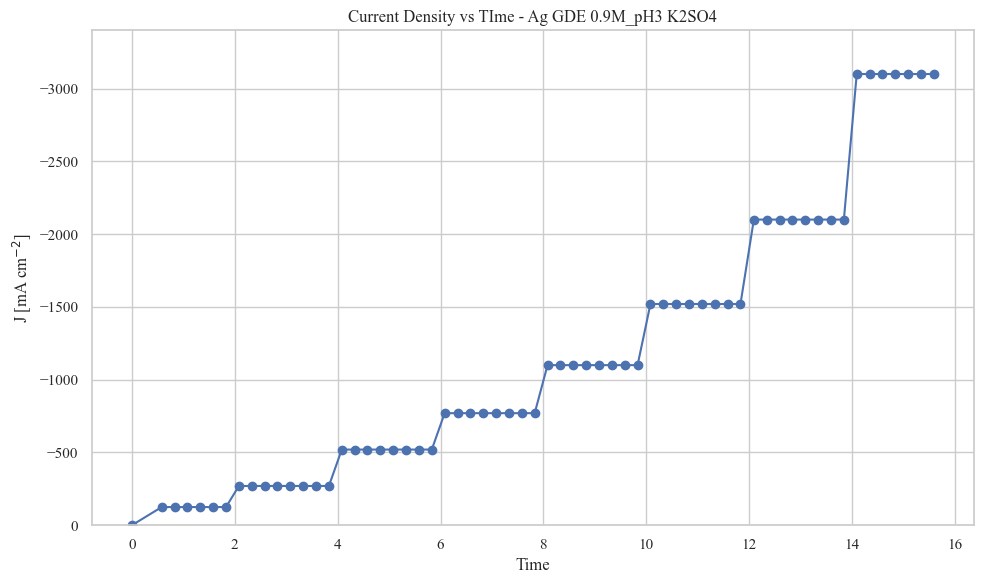

In [142]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH3 K2SO4')  
plt.xlabel('Time') 
plt.ylabel(r'J [mA cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

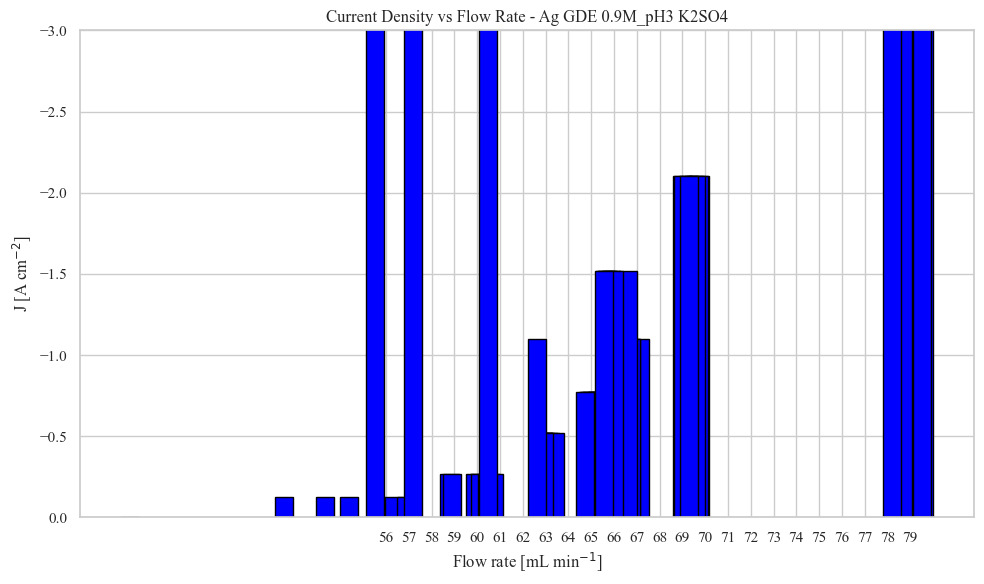

In [143]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH3 K2SO4')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


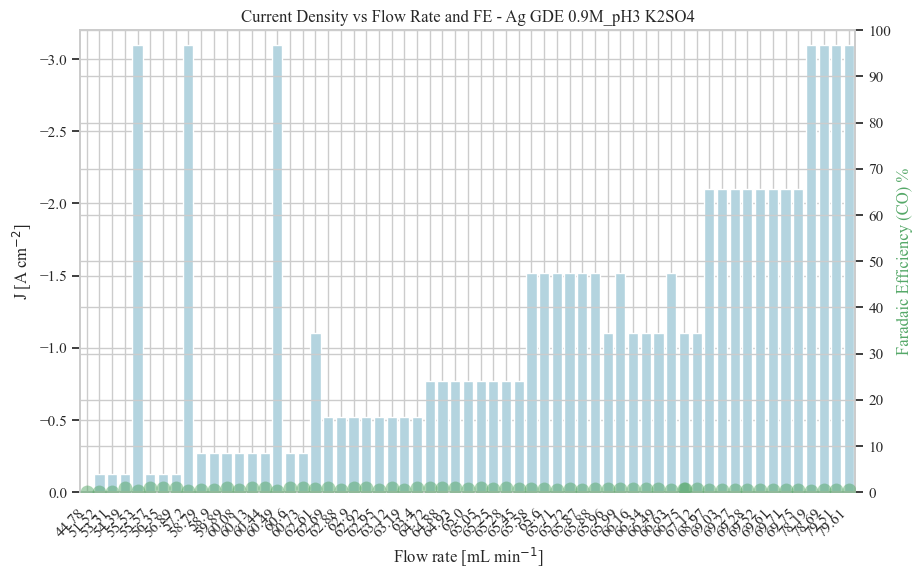

In [144]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH3 K2SO4')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240611_Ag_GDE_0_9M_pH3_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [145]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [146]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\K2SO4\20240611 - Ag60 GDE_0.9 M K2SO4_pH3

11-Aug-26  10:00 AM    <DIR>          .
07-Jun-26  07:23 PM    <DIR>          ..
07-Jun-26  09:50 PM    <DIR>          .ipynb_checkpoints
12-Jun-24  11:44 AM            36,247 0p9M_pH3 K2SO4_20240612_0944_1min - Copy.xlsx
30-Jul-26  11:50 AM            43,948 0p9M_pH3 K2SO4_20240612_0944_1min.xlsx
12-Jun-24  11:44 AM            11,575 0p9M_pH3 K2SO4_20240612_0944_5min.xlsx
12-Jun-24  11:44 AM           247,066 0p9M_pH3 K2SO4_20240612_0944_Line_1.csv
12-May-25  02:06 PM           685,010 20240611 - Ag60 GDE_0.9 M K2SO4_pH3.ipynb
11-Aug-26  10:00 AM           632,815 20240611 - Ag60 GDE_0.9 M K2SO4_pH3-CORRECTED.ipynb
11-Aug-26  09:57 AM               577 20240611_0.9 M K2SO4_pH3_Energy Consumption.csv
03-Aug-26  05:44 PM             5,305 20240611_0.9M K2SO4_pH3.csv
11-Aug-26  09:57 AM             1,402 20

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


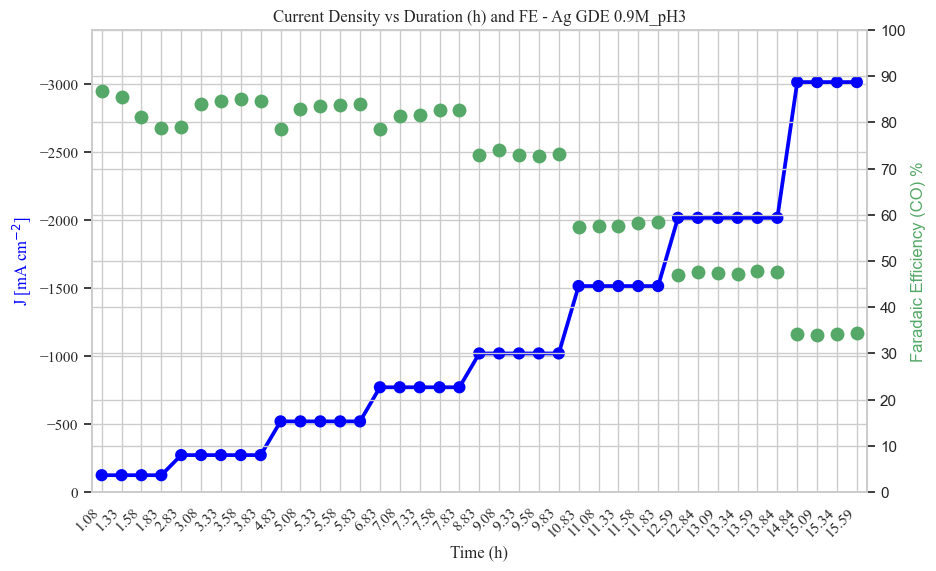

In [147]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH3')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240611_Ag_GDE_0_9M_pH3_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initilal step in each current

In [148]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 0.83].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 2.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 4.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 6.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.58].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.08].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.33].index)
rows = rows.drop(rows[rows['Duration / h'] == 10.58].index)

rows = rows.drop(rows[rows['Duration / h'] == 12.09].index)
rows = rows.drop(rows[rows['Duration / h'] == 12.34].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.09].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.34].index)
rows = rows.drop(rows[rows['Duration / h'] == 14.59].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
3,Ag60 GDE in PTFE holder,60.0,54.39,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:12:44,1.08,0.150315,...,54.39,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,93.873611
4,Ag60 GDE in PTFE holder,60.0,55.57,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:27:44,1.33,0.166076,...,55.57,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,93.426578
5,Ag60 GDE in PTFE holder,60.0,56.35,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:42:45,1.58,0.183679,...,56.35,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,90.137163
6,Ag60 GDE in PTFE holder,60.0,56.89,K2SO4,0.05 M H2SO4,CCM-CEM,-0.124,2024-06-11 17:57:45,1.83,0.194785,...,56.89,1.0,-124.0,0.125,0.124,53.11011,43.453749,58.203984,54.449562,88.624637
7,Ag60 GDE in PTFE holder,60.0,60.73,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:57:48,3.83,0.227660,...,60.73,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.685403
8,Ag60 GDE in PTFE holder,60.0,60.44,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:42:48,3.58,0.222699,...,60.44,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.906034
9,Ag60 GDE in PTFE holder,60.0,60.13,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:12:47,3.08,0.211829,...,60.13,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,89.597577
10,Ag60 GDE in PTFE holder,60.0,60.60,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 19:27:48,3.33,0.218270,...,60.60,3.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,90.217312
14,Ag60 GDE in PTFE holder,60.0,59.89,K2SO4,0.05 M H2SO4,CCM-CEM,-0.272,2024-06-11 18:57:47,2.83,0.205780,...,59.89,2.0,-272.0,0.270,0.272,58.912988,56.887299,60.113919,59.013348,84.509451
18,Ag60 GDE in PTFE holder,60.0,62.69,K2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-06-11 20:57:52,4.83,0.357520,...,62.69,4.0,-520.0,0.520,0.520,59.730733,58.643768,60.888128,59.711483,83.311175


## Current Density vs FE(CO)_ mean and std

### Stacked bar plot

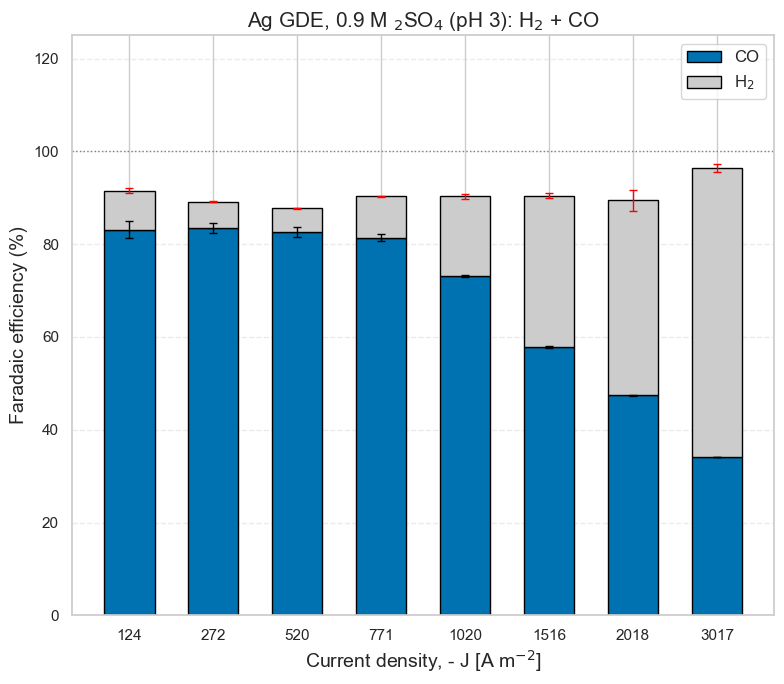

In [149]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M $_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

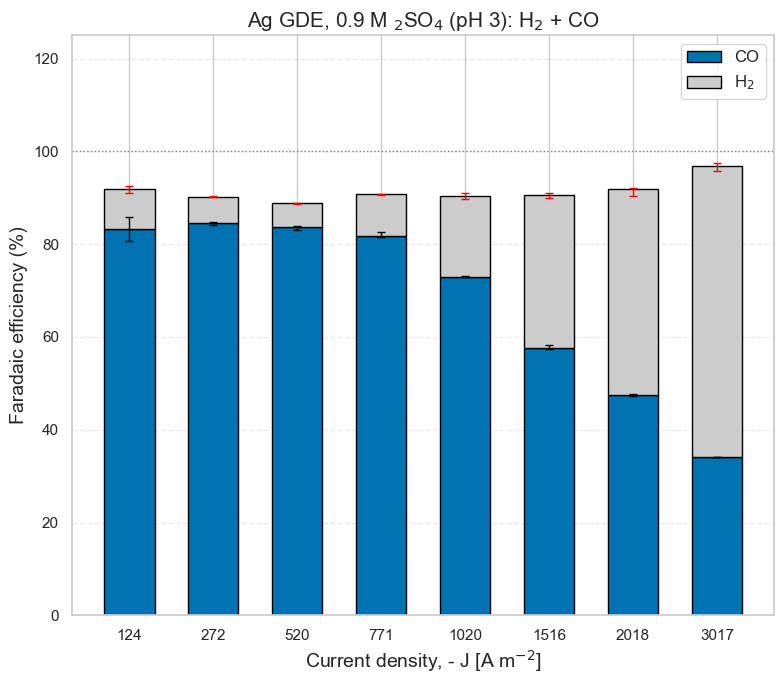

In [152]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M $_2$SO$_4$ (pH 3): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [153]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [154]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,8.431349,83.084148,8.447030,83.334841,0.596611,1.852263,1.193223,3.704527,7.772886,...,0.001459,4,0.674143,0.658463,2.681302,2.430609,2.022839,1.756466,0–2,124
1,250,5.668968,83.514187,5.653687,84.563626,0.098842,1.116513,0.221018,2.496598,5.499403,...,0.001976,5,0.154283,0.174953,0.465452,0.175080,0.619736,0.468091,2–4,272
2,500,5.122147,82.609325,5.212901,83.647153,0.092809,1.033971,0.207527,2.312030,5.084528,...,0.003443,5,0.128373,0.046214,0.655709,0.158284,0.784082,0.204499,4–6,520
3,750,8.863548,81.410817,9.043905,81.684404,0.205093,0.766659,0.458602,1.714303,8.910935,...,0.008801,5,0.132970,0.046693,0.236292,0.920224,0.369262,0.966917,6–8,771
4,1000,17.175164,73.166397,17.430809,72.976398,0.525738,0.240388,1.175585,0.537524,16.682347,...,0.022100,5,0.748462,0.623825,0.063164,0.134822,0.372000,0.009701,8–10,1020
5,1500,32.625244,57.834752,33.056261,57.542705,0.568540,0.250349,1.271295,0.559797,32.398249,...,0.059483,5,0.658012,0.367064,0.057119,0.777346,0.600893,1.201529,10–12,1516
6,2000,41.986725,47.431678,44.431578,47.457486,2.218773,0.139533,5.434861,0.341784,42.915802,...,0.101291,6,1.515777,0.288854,0.167762,0.223468,1.306124,0.639717,12–14,2018
7,3000,62.304512,34.125861,62.635899,34.118082,0.794855,0.097188,1.589709,0.194375,61.660612,...,0.188812,4,0.975287,0.643900,0.067690,0.075468,1.042977,0.822032,14–16,3017


In [157]:
Res_Book
# Res_Book.to_csv('20240611_0.9M K2SO4_pH3.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,8.431349,83.084148,8.447030,83.334841,0.596611,1.852263,1.193223,3.704527,7.772886,...,0.001459,4,0.674143,0.658463,2.681302,2.430609,2.022839,1.756466,0–2,124
1,250,5.668968,83.514187,5.653687,84.563626,0.098842,1.116513,0.221018,2.496598,5.499403,...,0.001976,5,0.154283,0.174953,0.465452,0.175080,0.619736,0.468091,2–4,272
2,500,5.122147,82.609325,5.212901,83.647153,0.092809,1.033971,0.207527,2.312030,5.084528,...,0.003443,5,0.128373,0.046214,0.655709,0.158284,0.784082,0.204499,4–6,520
3,750,8.863548,81.410817,9.043905,81.684404,0.205093,0.766659,0.458602,1.714303,8.910935,...,0.008801,5,0.132970,0.046693,0.236292,0.920224,0.369262,0.966917,6–8,771
4,1000,17.175164,73.166397,17.430809,72.976398,0.525738,0.240388,1.175585,0.537524,16.682347,...,0.022100,5,0.748462,0.623825,0.063164,0.134822,0.372000,0.009701,8–10,1020
5,1500,32.625244,57.834752,33.056261,57.542705,0.568540,0.250349,1.271295,0.559797,32.398249,...,0.059483,5,0.658012,0.367064,0.057119,0.777346,0.600893,1.201529,10–12,1516
6,2000,41.986725,47.431678,44.431578,47.457486,2.218773,0.139533,5.434861,0.341784,42.915802,...,0.101291,6,1.515777,0.288854,0.167762,0.223468,1.306124,0.639717,12–14,2018
7,3000,62.304512,34.125861,62.635899,34.118082,0.794855,0.097188,1.589709,0.194375,61.660612,...,0.188812,4,0.975287,0.643900,0.067690,0.075468,1.042977,0.822032,14–16,3017


## Mean and StD of FE(CO) through time

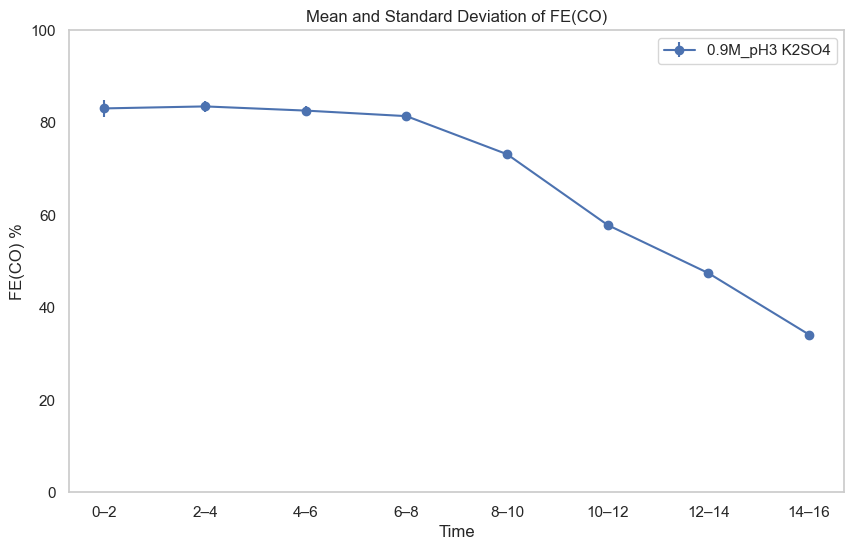

In [158]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.9M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240611_0.9M_pH3_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

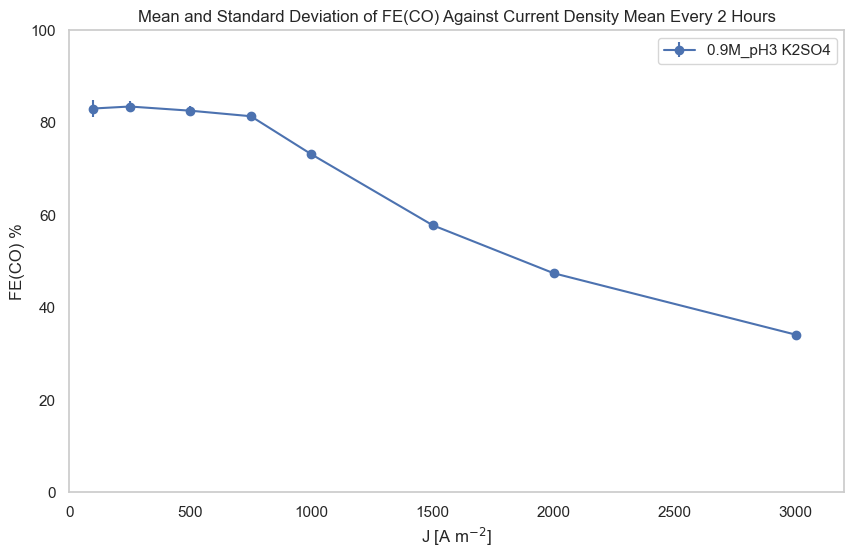

In [159]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_sem'], fmt='-o', label='0.9M_pH3 K2SO4')

# Formatting the plot
ax.set_xlabel(r'J [A m$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3200)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240611_0.9M_pH3_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()